# 01 — Auditoria e Preparação dos Dados

## Objetivo

Este notebook inicia o projeto pela etapa mais importante: compreender e auditar os dados antes
de qualquer limpeza, engenharia de atributos ou modelagem.

O objetivo não é procurar evidências para confirmar uma hipótese previamente escolhida. O objetivo
é testar sistematicamente a integridade das fontes, identificar comportamentos incomuns e separar:

- **erro confirmado**: viola uma regra verificável dos dados ou do domínio;
- **anomalia**: comportamento raro que merece investigação, mas pode ser legítimo;
- **hipótese operacional**: interpretação que depende de confirmação externa;
- **dado válido**: comportamento consistente com as evidências disponíveis.

### Princípios adotados

1. Os arquivos brutos são imutáveis.
2. Nenhum registro será removido apenas por apresentar volume elevado ou comportamento incomum.
3. Toda decisão deve seguir a sequência **evidência → interpretação → decisão → impacto**.
4. Ausência de evidência não será tratada como evidência de falha, parada ou defeito de sensor.
5. Alterações futuras deverão apresentar contagens antes/depois e uma justificativa reproduzível.
6. `Is_Dont_Go` será inicialmente tratado conforme sua descrição no dicionário, sem assumir que
   representa uma falha física ou parada confirmada.

> **Escopo desta etapa:** detectar, quantificar e documentar. As análises abaixo criam candidatos
> para tratamento, mas preservam os dados até que exista justificativa suficiente.

## 1. Configuração reproduzível

Todos os caminhos são relativos à raiz do projeto. DuckDB é usado para consultar os arquivos
Parquet sem carregar dezenas de milhões de linhas integralmente na memória. Pandas é reservado
para tabelas pequenas, resultados agregados e leitura dos arquivos Excel.

Também registramos as versões das bibliotecas. Isso permite investigar diferenças caso o notebook
seja executado futuramente em outro ambiente.

In [1]:
from pathlib import Path
import platform

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")
AP_PATH = str(BASE / "datasets" / "apontamentos" / "desenvolver_apontamentos.parquet")
DICT_PATH = BASE / "Dicionario_Dados.xlsx"
RULES_PATH = BASE / "Alarmes - Regra de Negocio.xlsx"

required = [BASE, Path(AP_PATH), DICT_PATH, RULES_PATH]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Fontes obrigatórias ausentes: {missing}")

con = duckdb.connect()
con.execute("SET threads=4")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")
con.execute(f"CREATE OR REPLACE VIEW ap AS SELECT * FROM read_parquet('{AP_PATH}')")

def query(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

versions = pd.DataFrame({
    "componente": ["Python", "pandas", "numpy", "duckdb"],
    "versao": [platform.python_version(), pd.__version__, np.__version__, duckdb.__version__],
})
display(versions)
print(f"Raiz do projeto: {ROOT}")

,componente,versao
0,Python,3.12.3
1,pandas,3.0.3
2,numpy,2.4.6
3,duckdb,1.5.3


Raiz do projeto: /home/f_szekut/projects/vale_correct


## 2. Inventário das fontes e contrato de dados

Antes de analisar conteúdo, verificamos se as colunas entregues correspondem ao dicionário de dados.
Uma coluna ausente, inesperada ou com tipo divergente pode indicar mudança de esquema entre arquivos.

O catálogo de regras também é inspecionado nesta etapa, mas ainda não é aplicado. Primeiro precisamos
entender quais condições ele exige e quais campos realmente existem na telemetria.

In [2]:
tel_schema = query("DESCRIBE SELECT * FROM tel")
ap_schema = query("DESCRIBE SELECT * FROM ap")
dict_tel = pd.read_excel(DICT_PATH, sheet_name="Telemetria")
dict_ap = pd.read_excel(DICT_PATH, sheet_name="Apontamentos")
rules = pd.read_excel(RULES_PATH, sheet_name="CMA")

inventory = pd.DataFrame([
    {"fonte": "Telemetria", "colunas_arquivo": len(tel_schema), "colunas_dicionario": len(dict_tel)},
    {"fonte": "Apontamentos", "colunas_arquivo": len(ap_schema), "colunas_dicionario": len(dict_ap)},
    {"fonte": "Regras CMA", "colunas_arquivo": len(rules.columns), "colunas_dicionario": np.nan},
])
display(inventory)

def compare_contract(schema: pd.DataFrame, dictionary: pd.DataFrame) -> pd.DataFrame:
    actual = set(schema["column_name"])
    documented = set(dictionary["Nome da Feature"])
    return pd.DataFrame({
        "teste": ["documentada_e_ausente", "presente_e_nao_documentada"],
        "colunas": [sorted(documented - actual), sorted(actual - documented)],
    })

print("Contrato — Telemetria")
display(compare_contract(tel_schema, dict_tel))
print("Contrato — Apontamentos")
display(compare_contract(ap_schema, dict_ap))
print("Estrutura das regras CMA")
display(rules.head())

,fonte,colunas_arquivo,colunas_dicionario
0,Telemetria,18,18.0
1,Apontamentos,7,9.0
2,Regras CMA,6,NaN


Contrato — Telemetria


,teste,colunas
0,documentada_e_ausente,[]
1,presente_e_nao_documentada,[]


Contrato — Apontamentos


,teste,colunas
0,documentada_e_ausente,"[Matricula_Operador_Hash, Nome_Operador_Anon]"
1,presente_e_nao_documentada,[]


Estrutura das regras CMA


,TIPO,EVENTO,SITUACAO,QTD,TEMPO,NIVEL
0,ALARME OEM,Low Transmission Oil Level,Mediante alarme nível 3,2,360,Muito Alto
1,ALARME OEM,Low Transmission Oil Level,Mediante cinco alarmes nivel 2 consecutivos.,5,360,Muito alto
2,ALARME OEM,Transmission Oil Level - Active,Mediante alarme nível 3,2,360,Muito Alto
3,ALARME OEM,Engine Coolant Level - Active,Mediante alarme nível 3,1,0,Muito Alto
4,ALARME OEM,Engine Coolant Level - Active,Mediante dez alarmes nivel 2 consecutivos.,10,360,Alto


## 3. Integridade estrutural e cobertura

Os primeiros testes procuram erros objetivos:

- IDs ausentes ou repetidos;
- datas ausentes;
- valores de target fora de `{0, 1}`;
- período e cardinalidade das fontes;
- colunas essenciais nulas.

Esses testes não interpretam o negócio. Eles verificam propriedades básicas necessárias para qualquer
análise posterior.

In [3]:
overview_tel = query(
    '''
    SELECT count(*) AS registros,
           count(DISTINCT Id_Eventos_Telemetria) AS ids_distintos,
           min(Data_Evento) AS inicio,
           max(Data_Evento) AS fim,
           count(DISTINCT TAG) AS tags,
           count(DISTINCT Id_Alarme) AS ids_alarme,
           count(DISTINCT Alarme) AS alarmes,
           sum(Is_Dont_Go) AS linhas_dont_go
    FROM tel
    '''
)
overview_ap = query(
    '''
    SELECT count(*) AS registros,
           count(DISTINCT Id) AS ids_distintos,
           min(Inicio) AS inicio,
           max(Fim) AS fim,
           count(DISTINCT Tag) AS tags
    FROM ap
    '''
)
display(overview_tel)
display(overview_ap)

essential_nulls = query(
    '''
    SELECT
      sum(Id_Eventos_Telemetria IS NULL) AS id_nulo,
      sum(Data_Evento IS NULL) AS data_nula,
      sum(TAG IS NULL) AS tag_nula,
      sum(Id_Alarme IS NULL) AS id_alarme_nulo,
      sum(Alarme IS NULL) AS alarme_nulo,
      sum(Is_Dont_Go IS NULL) AS target_nulo,
      sum(Is_Dont_Go NOT IN (0, 1)) AS target_fora_dominio
    FROM tel
    '''
)
display(essential_nulls)

# O resumo abaixo cobre todas as colunas, não apenas as essenciais. Nulos podem ser
# legítimos, mas precisam ser conhecidos antes de qualquer seleção de atributos.
null_expressions = ", ".join(
    f"sum({column} IS NULL) AS {column}" for column in tel_schema["column_name"]
)
null_profile_tel = query(f"SELECT {null_expressions} FROM tel").T.reset_index()
null_profile_tel.columns = ["coluna", "nulos"]
null_profile_tel["pct_nulos"] = null_profile_tel["nulos"] / int(overview_tel.loc[0, "registros"]) * 100
display(null_profile_tel.sort_values("pct_nulos", ascending=False))

,registros,ids_distintos,inicio,fim,tags,ids_alarme,alarmes,linhas_dont_go
0,37164054,37164054,2025-01-01 00:00:00.017,2025-06-30 23:59:56.887,35,1324,712,19962.0


,registros,ids_distintos,inicio,fim,tags
0,377907,377907,2025-01-01,2025-07-01,47


,id_nulo,data_nula,tag_nula,id_alarme_nulo,alarme_nulo,target_nulo,target_fora_dominio
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,coluna,nulos,pct_nulos
0,Id_Eventos_Telemetria,0.0,0.0
1,Data_Evento,0.0,0.0
2,Inicio_Turno,0.0,0.0
3,Fim_Turno,0.0,0.0
4,Dia,0.0,0.0
5,Localidade,0.0,0.0
6,TAG,0.0,0.0
7,Tag_Frota,0.0,0.0
8,Tipo,0.0,0.0
9,Nome_Operador_Anon,0.0,0.0


## 4. Consistência semântica entre colunas

Alguns erros não aparecem como nulos. Por exemplo, o mesmo `Id_Alarme` pode estar associado a nomes
diferentes, uma TAG pode aparecer com frotas incompatíveis ou a coluna `Dia` pode discordar da data.

Testamos relações esperadas sem assumir antecipadamente que qualquer divergência é erro. Divergências
são apresentadas para investigação; algumas podem representar mudanças legítimas ao longo do tempo.

In [4]:
semantic_tests = query(
    '''
    SELECT
      sum(Dia <> day(Data_Evento)) AS dia_incompativel_com_data,
      sum(trim(TAG) <> TAG) AS tag_com_espacos_externos,
      sum(trim(Alarme) <> Alarme) AS alarme_com_espacos_externos,
      sum(TAG !~ '^[A-Za-z]{2}[0-9]+$') AS tag_fora_padrao_observado
    FROM tel
    '''
)
display(semantic_tests)

alarm_mapping_conflicts = query(
    '''
    SELECT Id_Alarme, count(DISTINCT Alarme) AS nomes,
           list(DISTINCT Alarme ORDER BY Alarme) AS valores
    FROM tel
    GROUP BY Id_Alarme
    HAVING count(DISTINCT Alarme) > 1
    ORDER BY nomes DESC, Id_Alarme
    '''
)
tag_profile_conflicts = query(
    '''
    SELECT TAG,
           count(DISTINCT Tag_Frota) AS tag_frotas,
           count(DISTINCT Tipo) AS tipos,
           count(DISTINCT Localidade) AS localidades,
           list(DISTINCT Tag_Frota ORDER BY Tag_Frota) AS valores_frota,
           list(DISTINCT Tipo ORDER BY Tipo) AS valores_tipo
    FROM tel
    GROUP BY TAG
    HAVING count(DISTINCT Tag_Frota) > 1 OR count(DISTINCT Tipo) > 1
    ORDER BY TAG
    '''
)
print(f"IDs de alarme associados a múltiplos nomes: {len(alarm_mapping_conflicts)}")
display(alarm_mapping_conflicts.head(20))
print(f"TAGs com mais de uma frota ou tipo: {len(tag_profile_conflicts)}")
display(tag_profile_conflicts)

# Espaços externos são um problema de padronização confirmado porque duas strings
# semanticamente iguais passam a ser tratadas como categorias diferentes.
alarm_whitespace = query(
    '''
    SELECT Alarme, trim(Alarme) AS alarme_sem_espacos,
           count(*) AS registros,
           count(DISTINCT Id_Alarme) AS ids_alarme
    FROM tel
    WHERE trim(Alarme) <> Alarme
    GROUP BY 1, 2
    ORDER BY registros DESC
    LIMIT 30
    '''
)
display(alarm_whitespace)

# Também verificamos se a normalização por trim reduz conflitos entre ID e nome.
# Isso mede o impacto da inconsistência sem alterar os dados brutos.
mapping_impact = query(
    '''
    SELECT
      count(*) FILTER (WHERE nomes_originais > 1) AS ids_conflitantes_original,
      count(*) FILTER (WHERE nomes_sem_espacos > 1) AS ids_conflitantes_apos_trim
    FROM (
      SELECT Id_Alarme,
             count(DISTINCT Alarme) AS nomes_originais,
             count(DISTINCT trim(Alarme)) AS nomes_sem_espacos
      FROM tel GROUP BY Id_Alarme
    )
    '''
)
display(mapping_impact)

,dia_incompativel_com_data,tag_com_espacos_externos,alarme_com_espacos_externos,tag_fora_padrao_observado
0,0.0,0.0,530241.0,0.0


IDs de alarme associados a múltiplos nomes: 122


,Id_Alarme,nomes,valores
0,16830976,3,"[MC - QUEDA NA PRESS??O ÓLEO MOTOR <270KPA, MC..."
1,16831802,2,"[MC - QUEDA PRESSÃO DO ??LEO MOTOR, MC - QUEDA..."
2,16832115,2,"[MC - TEMPERATURA DA DIREÇ??O >95C, MC - TEMPE..."
3,16833710,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA..."
4,16833711,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA..."
5,16833712,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA..."
6,16833713,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA..."
7,16833714,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA..."
8,16833715,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA..."
9,16833716,2,"[TESTE-OP ENTRADA ARTICULADA, TESTE-OP ENTRADA..."


TAGs com mais de uma frota ou tipo: 0


,TAG,tag_frotas,tipos,localidades,valores_frota,valores_tipo


,Alarme,alarme_sem_espacos,registros,ids_alarme
0,Dipper,Dipper,529454,1
1,Oem Interface Timeout,Oem Interface Timeout,424,1
2,Oem Interface Normal,Oem Interface Normal,362,1
3,BASCULAMENTO-PREDITIVA ONLINE,BASCULAMENTO-PREDITIVA ONLINE,1,1


,ids_conflitantes_original,ids_conflitantes_apos_trim
0,122,120


## 5. Coerência temporal e continuidade

Verificamos a cobertura diária e a coerência dos turnos. Uma data sem registros confirma uma lacuna
na fonte, mas não permite concluir sua causa. Da mesma forma, eventos fora do intervalo declarado
do turno podem indicar erro de atribuição, formato inesperado ou regra de borda.

Por isso, a decisão nesta etapa é apenas registrar e quantificar as inconsistências.

,inicio_turno_nao_convertivel,fim_turno_nao_convertivel,turno_duracao_invalida,evento_fora_turno
0,0.0,0.0,0.0,0.0


,data,registros,tags,linhas_dont_go
150,2025-05-31,0.0,0.0,0.0


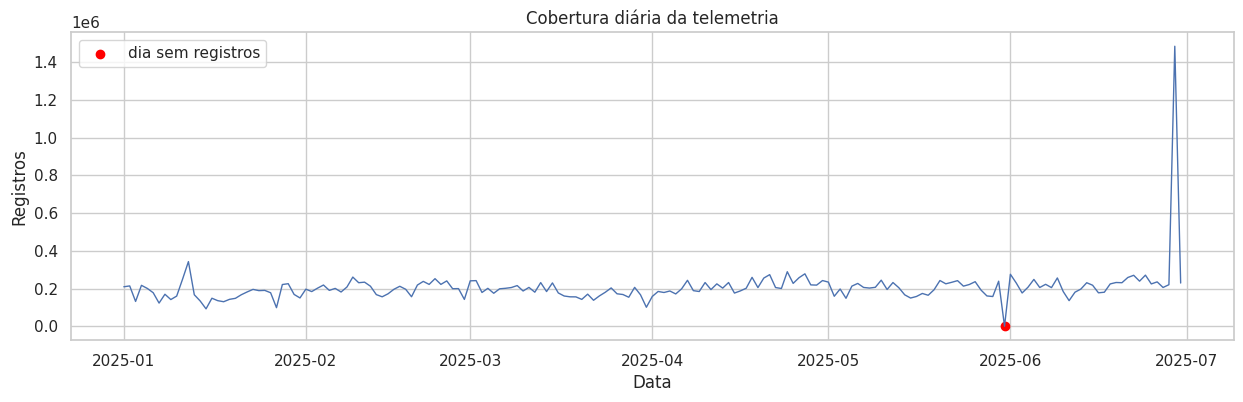

In [5]:
temporal_checks = query(
    '''
    WITH parsed AS (
      SELECT Data_Evento,
             try_cast(Inicio_Turno AS TIMESTAMP) AS inicio_turno_ts,
             try_cast(Fim_Turno AS TIMESTAMP) AS fim_turno_ts
      FROM tel
    )
    SELECT
      sum(inicio_turno_ts IS NULL) AS inicio_turno_nao_convertivel,
      sum(fim_turno_ts IS NULL) AS fim_turno_nao_convertivel,
      sum(fim_turno_ts <= inicio_turno_ts) AS turno_duracao_invalida,
      sum(Data_Evento < inicio_turno_ts OR Data_Evento > fim_turno_ts) AS evento_fora_turno
    FROM parsed
    '''
)
display(temporal_checks)

daily = query(
    '''
    SELECT cast(Data_Evento AS DATE) AS data,
           count(*) AS registros,
           count(DISTINCT TAG) AS tags,
           sum(Is_Dont_Go) AS linhas_dont_go
    FROM tel GROUP BY 1 ORDER BY 1
    '''
)
calendar = pd.DataFrame({"data": pd.date_range(daily["data"].min(), daily["data"].max(), freq="D")})
daily_complete = calendar.merge(daily, on="data", how="left").fillna(0)
missing_days = daily_complete[daily_complete["registros"] == 0]
display(missing_days)

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(daily_complete["data"], daily_complete["registros"], linewidth=1)
ax.scatter(missing_days["data"], missing_days["registros"], color="red", label="dia sem registros")
ax.set(title="Cobertura diária da telemetria", ylabel="Registros", xlabel="Data")
ax.legend()
plt.show()

## 6. Investigação de TAGs potencialmente inconsistentes

Erros de digitação em identificadores são comuns, portanto procuramos TAGs parecidas e comparamos
seus históricos. Entretanto, semelhança textual não autoriza a fusão de equipamentos.

Uma fusão só seria justificável se múltiplas evidências fossem compatíveis, como ausência de
coexistência temporal, mesma frota, mesmo tipo e continuidade operacional. Se TAGs semelhantes
coexistem ou possuem perfis próprios, elas devem ser preservadas como equipamentos distintos.

In [6]:
tag_profiles = query(
    '''
    SELECT TAG, Tag_Frota, Tipo,
           count(*) AS registros,
           min(Data_Evento) AS inicio,
           max(Data_Evento) AS fim,
           sum(Is_Dont_Go) AS linhas_dont_go
    FROM tel
    GROUP BY TAG, Tag_Frota, Tipo
    ORDER BY TAG, Tag_Frota, Tipo
    '''
)

from difflib import SequenceMatcher

tags = sorted(tag_profiles["TAG"].unique())
similar_pairs = []
for i, left in enumerate(tags):
    for right in tags[i + 1:]:
        score = SequenceMatcher(None, left, right).ratio()
        if score >= 0.75:
            similar_pairs.append({"tag_a": left, "tag_b": right, "similaridade": score})

similar_pairs = pd.DataFrame(similar_pairs).sort_values("similaridade", ascending=False)
display(similar_pairs.head(30))

similar_tags = sorted(set(similar_pairs["tag_a"]).union(similar_pairs["tag_b"]))
display(tag_profiles[tag_profiles["TAG"].isin(similar_tags)])

print("Decisão desta etapa: preservar todas as TAGs. Similaridade textual é apenas um sinal para investigação.")

,tag_a,tag_b,similaridade
24,CA5927,CA65927,0.923077
9,CA5926,CA65926,0.923077
30,CA65789,CA65791,0.857143
31,CA65789,CA65792,0.857143
60,CA65793,CA65930,0.857143
61,CA65793,CA65931,0.857143
62,CA65793,CA65932,0.857143
63,CA65793,CA65933,0.857143
34,CA65790,CA65792,0.857143
33,CA65790,CA65791,0.857143


,TAG,Tag_Frota,Tipo,registros,inicio,fim,linhas_dont_go
0,CA5926,793-D 5S,Caminhao,107226,2025-01-01 00:00:14.553,2025-06-30 23:57:52.887,472.0
1,CA5927,793-D 5S,Caminhao,54286,2025-01-01 00:31:25.447,2025-06-30 23:56:30.337,471.0
2,CA65789,793-D 2S,Caminhao,48872,2025-01-01 00:07:59.473,2025-06-30 23:55:47.217,39.0
3,CA65790,793-D 2S,Caminhao,155029,2025-01-01 00:05:37.580,2025-06-30 23:55:10.460,65.0
4,CA65791,793-D 2S,Caminhao,871,2025-06-26 14:59:19.650,2025-06-29 19:20:39.630,0.0
5,CA65792,793-D 2S,Caminhao,126551,2025-01-01 00:00:05.790,2025-06-30 23:53:35.513,1589.0
6,CA65793,793-D 2S,Caminhao,49657,2025-04-08 15:43:52.703,2025-06-30 23:59:40.767,6.0
7,CA65902,793-D 3S,Caminhao,25382,2025-01-01 00:00:53.513,2025-04-04 13:46:12.477,418.0
8,CA65908,793-D 3S,Caminhao,32423,2025-01-01 00:20:11.913,2025-04-17 17:56:37.153,703.0
9,CA65909,793-D 3S,Caminhao,107325,2025-01-01 00:06:15.740,2025-06-30 23:50:46.827,229.0


Decisão desta etapa: preservar todas as TAGs. Similaridade textual é apenas um sinal para investigação.


## 7. Duplicidades e repetições temporais

Distinguimos dois fenômenos:

- **ID repetido:** erro objetivo, pois o identificador deveria ser único.
- **evento lógico repetido:** mesmas informações essenciais em mais de uma linha, mas IDs diferentes.

Eventos lógicos repetidos podem ser duplicação de ingestão, retransmissão ou comportamento legítimo
do equipamento. Portanto, serão quantificados e marcados, não excluídos automaticamente.

In [7]:
duplicates = query(
    '''
    SELECT
      count(*) - count(DISTINCT Id_Eventos_Telemetria) AS ids_repetidos_excedentes,
      count(*) - count(DISTINCT (Data_Evento, TAG, Id_Alarme, Valor, Classe, Is_Dont_Go))
        AS eventos_logicos_repetidos_excedentes
    FROM tel
    '''
)
display(duplicates)

duplicate_groups = query(
    '''
    SELECT TAG, Data_Evento, Id_Alarme, Alarme, Valor, Classe, Is_Dont_Go,
           count(*) AS repeticoes
    FROM tel
    GROUP BY ALL
    HAVING count(*) > 1
    ORDER BY repeticoes DESC, TAG, Data_Evento
    LIMIT 30
    '''
)
display(duplicate_groups)

positive_repetition = query(
    '''
    WITH gaps AS (
      SELECT TAG, Alarme, Data_Evento,
             date_diff('second',
               lag(Data_Evento) OVER (PARTITION BY TAG, Alarme ORDER BY Data_Evento),
               Data_Evento) AS gap_s
      FROM tel WHERE Is_Dont_Go = 1
    )
    SELECT count(*) AS linhas_positivas,
           sum(gap_s BETWEEN 0 AND 60) AS repeticao_ate_1_min,
           sum(gap_s BETWEEN 0 AND 3600) AS repeticao_ate_1_h,
           median(gap_s) AS mediana_gap_s
    FROM gaps
    '''
)
display(positive_repetition)

,ids_repetidos_excedentes,eventos_logicos_repetidos_excedentes
0,0,265574


,TAG,Data_Evento,Id_Alarme,Alarme,Valor,Classe,Is_Dont_Go,repeticoes
0,CA65925,2025-01-12 22:39:35.000,16832536,OP - FALHA NO FREIO RETARDO AUTOMÁTICO,NULL,NULL,0,4
1,CA65925,2025-01-12 23:55:18.000,16832536,OP - FALHA NO FREIO RETARDO AUTOMÁTICO,NULL,NULL,0,4
2,CA65930,2025-01-06 06:00:00.000,335609862,1st Tire Tag Timeout,0,NULL,0,4
3,PE3798,2025-03-01 18:00:00.000,1241579532,Engine \/ Retarder Torque Mode - Not Defined\/...,0,NULL,0,4
4,PE3799,2025-04-29 06:00:00.000,1074008257,Dump Wheel Limited By End Of Travel (L-1850),0,NULL,0,4
5,CA5927,2025-04-22 18:07:05.137,16833326,MA - BAIXA VOLTAGEM COM EQUIP. DESLIGADO <24V,NULL,NULL,0,3
6,CA65936,2025-02-02 01:10:04.000,16833576,MA - Dif Temp Exaust > 60 ºC,NULL,NULL,0,3
7,PE3795,2025-04-27 09:55:52.420,16831444,MC - ALTA TEMP. ARREF. DO MOTOR >90°C,NULL,NULL,0,3
8,PE3795,2025-04-27 11:10:25.687,16831444,MC - ALTA TEMP. ARREF. DO MOTOR >90°C,NULL,NULL,0,3
9,CA5926,2025-01-11 18:04:22.153,335609935,Rx Channel B Not Receiving Messages,0,NULL,0,2


,linhas_positivas,repeticao_ate_1_min,repeticao_ate_1_h,mediana_gap_s
0,19962,4401.0,15534.0,274.0


### 7.1 Separação entre duplicata exata e repetição lógica

O critério lógico anterior ignora campos contextuais como operador, turno e criticidade. Para evitar
remover registros legitimamente distintos, comparamos também todas as colunas da telemetria, exceto
o identificador `Id_Eventos_Telemetria`.

Quando duas linhas são iguais em todas as demais colunas e diferem somente pelo ID, há evidência
suficiente para classificá-las como duplicatas exatas na camada analítica. Os dados brutos continuam
preservados e o ID removido deve permanecer registrado em uma tabela de controle.

In [8]:
exact_duplicates = query(
    '''
    SELECT
      count(*) - count(DISTINCT (
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme, Id_Criticidade,
        Criticidade, Valor, Classe, Is_Dont_Go
      )) AS duplicatas_exatas_excedentes,
      count(*) - count(DISTINCT (
        Data_Evento, TAG, Id_Alarme, Valor, Classe, Is_Dont_Go
      )) AS repeticoes_logicas_excedentes
    FROM tel
    '''
)
display(exact_duplicates)

exact_duplicate_summary = query(
    '''
    WITH groups AS (
      SELECT
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme, Id_Criticidade,
        Criticidade, Valor, Classe, Is_Dont_Go, count(*) AS repeticoes
      FROM tel
      GROUP BY ALL
      HAVING count(*) > 1
    )
    SELECT count(*) AS grupos_duplicados,
           sum(repeticoes - 1) AS duplicatas_exatas_excedentes,
           sum(CASE WHEN Is_Dont_Go = 1 THEN repeticoes - 1 ELSE 0 END)
             AS duplicatas_exatas_positivas
    FROM groups
    '''
)
display(exact_duplicate_summary)

print(
    "Decisão: deduplicação exata aprovada somente para a futura camada analítica. "
    "Repetições lógicas não exatas permanecem preservadas para investigação."
)

,duplicatas_exatas_excedentes,repeticoes_logicas_excedentes
0,265564,265574


,grupos_duplicados,duplicatas_exatas_excedentes,duplicatas_exatas_positivas
0,265556,265564.0,21.0


Decisão: deduplicação exata aprovada somente para a futura camada analítica. Repetições lógicas não exatas permanecem preservadas para investigação.


## 8. Anomalias de volume por equipamento e dia

Volume elevado pode indicar repetição anormal, operação intensa, mudança de configuração ou outra
condição legítima. Para evitar seleção manual, usamos um critério reproduzível por equipamento:

- calculamos mediana e MAD (*median absolute deviation*) do volume diário de cada TAG;
- marcamos como candidato o dia cujo volume excede `mediana + 10 × MAD`;
- mostramos composição, timestamps distintos, alarmes distintos e target.

O multiplicador 10 é deliberadamente conservador. A flag identifica candidatos para investigação;
ela não classifica automaticamente um sensor como defeituoso e não remove linhas.

In [9]:
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE tag_day AS
    SELECT TAG, cast(Data_Evento AS DATE) AS data,
           count(*) AS registros,
           count(DISTINCT Data_Evento) AS timestamps_distintos,
           count(DISTINCT Alarme) AS alarmes_distintos,
           sum(Is_Dont_Go) AS linhas_dont_go
    FROM tel GROUP BY 1, 2
    '''
)
volume_anomalies = query(
    '''
    WITH med AS (
      SELECT TAG, median(registros) AS mediana_registros
      FROM tag_day GROUP BY TAG
    ), stats AS (
      SELECT d.TAG, m.mediana_registros,
             median(abs(d.registros - m.mediana_registros)) AS mad_registros
      FROM tag_day d JOIN med m USING (TAG)
      GROUP BY d.TAG, m.mediana_registros
    )
    SELECT d.*, s.mediana_registros, s.mad_registros,
           d.registros > s.mediana_registros + 10 * greatest(s.mad_registros, 1)
             AS flag_volume_anomalo
    FROM tag_day d JOIN stats s USING (TAG)
    ORDER BY d.registros DESC
    '''
)
print(f"Combinações TAG/dia marcadas: {volume_anomalies['flag_volume_anomalo'].sum():,}")
display(volume_anomalies.head(30))

Combinações TAG/dia marcadas: 58


,TAG,data,registros,timestamps_distintos,alarmes_distintos,linhas_dont_go,mediana_registros,mad_registros,flag_volume_anomalo
0,PE3798,2025-06-29,1334065,1317842,39,0.0,41714.0,8429.0,True
1,PE3797,2025-01-12,136880,48383,37,0.0,55229.0,11414.0,False
2,PE3797,2025-02-23,94510,93424,41,0.0,55229.0,11414.0,False
3,PE3799,2025-02-04,90778,90082,33,0.0,48386.5,13244.5,False
4,PE3797,2025-02-09,87507,86539,39,0.0,55229.0,11414.0,False
5,PE3799,2025-02-09,85997,85241,37,0.0,48386.5,13244.5,False
6,PE3797,2025-06-27,85973,85028,38,0.0,55229.0,11414.0,False
7,PE3797,2025-02-25,85296,84423,40,0.0,55229.0,11414.0,False
8,PE3797,2025-02-16,84364,83614,31,0.0,55229.0,11414.0,False
9,PE3799,2025-02-12,83304,82752,31,0.0,48386.5,13244.5,False


### 8.1 Composição dos maiores candidatos

A composição ajuda a distinguir cenários. Muitos registros com poucos alarmes alternando rapidamente
é diferente de muitos registros distribuídos entre diversos alarmes. Ainda assim, nenhuma dessas
características prova isoladamente defeito de sensor.

Selecionamos os maiores candidatos derivados pelo critério anterior, sem escolher datas manualmente.

In [10]:
top_candidates = volume_anomalies[volume_anomalies["flag_volume_anomalo"]].head(10)[["TAG", "data"]]
con.register("top_candidates", top_candidates)

candidate_composition = query(
    '''
    SELECT t.TAG, cast(t.Data_Evento AS DATE) AS data, t.Alarme, t.Valor,
           count(*) AS registros, sum(t.Is_Dont_Go) AS linhas_dont_go
    FROM tel t
    JOIN top_candidates c
      ON t.TAG = c.TAG AND cast(t.Data_Evento AS DATE) = c.data
    GROUP BY 1, 2, 3, 4
    QUALIFY row_number() OVER (PARTITION BY t.TAG, cast(t.Data_Evento AS DATE)
                              ORDER BY count(*) DESC) <= 5
    ORDER BY t.TAG, data, registros DESC
    '''
)
display(candidate_composition)

print("Decisão desta etapa: manter os registros e carregar a flag de anomalia para análises posteriores.")

,TAG,data,Alarme,Valor,registros,linhas_dont_go
0,CA65931,2025-03-09,Engine Coolant Level - Inactive,2,3742,0.0
1,CA65931,2025-03-09,Engine Coolant Level - Active,2,3735,372.0
2,CA65931,2025-03-09,Rx Channel A Not Receiving Messages,0,108,0.0
3,CA65931,2025-03-09,5th Tire Tag Timeout,0,107,0.0
4,CA65931,2025-03-09,Rx Channel B Not Receiving Messages,0,107,0.0
5,CA65932,2025-03-25,Final Drive Bypass Solenoid - Active,2,4482,0.0
6,CA65932,2025-03-25,Final Drive Bypass Solenoid - Inactive,2,4472,0.0
7,CA65932,2025-03-25,Cycle,0,26,0.0
8,CA65932,2025-03-25,Body Up,4,26,0.0
9,CA65932,2025-03-25,Payload Overload - Active,2,8,0.0


Decisão desta etapa: manter os registros e carregar a flag de anomalia para análises posteriores.


### 8.2 Drill-down do maior candidato: PE3798 em 29/06/2025

O maior volume identificado pelo critério reproduzível foi a TAG `PE3798` em **29/06/2025**.
Não existe telemetria de julho na fonte analisada; portanto, qualquer referência a 29/07 deve ser
tratada como possível erro de data até que outra fonte seja disponibilizada.

Para decidir se o volume representa atividade legítima, duplicação ou emissão anormal, avaliamos:

1. magnitude em relação ao próprio histórico da TAG;
2. contribuição de cada alarme;
3. unicidade de IDs e eventos lógicos;
4. cadência e alternância dos sinais dominantes;
5. distribuição ao longo do dia e entre operadores;
6. situação operacional registrada nos apontamentos.

O objetivo não é decidir antecipadamente que houve falha de sensor. Procuramos localizar exatamente
qual componente explica a discrepância e qual tratamento seria proporcional às evidências.

In [11]:
pe3798_day_comparison = query(
    '''
    WITH daily AS (
      SELECT cast(Data_Evento AS DATE) AS data, count(*) AS registros
      FROM tel WHERE TAG = 'PE3798' GROUP BY 1
    ), reference AS (
      SELECT median(registros) AS mediana_outros_dias,
             quantile_cont(registros, 0.95) AS p95_outros_dias,
             max(registros) AS max_outros_dias
      FROM daily WHERE data <> DATE '2025-06-29'
    ), target_day AS (
      SELECT registros AS registros_29_06
      FROM daily WHERE data = DATE '2025-06-29'
    )
    SELECT *,
           registros_29_06 / mediana_outros_dias AS razao_mediana,
           registros_29_06 / max_outros_dias AS razao_max_anterior
    FROM reference, target_day
    '''
)
display(pe3798_day_comparison)

pe3798_top_signals = query(
    '''
    SELECT trim(Alarme) AS alarme, Valor, Criticidade,
           count(*) AS registros,
           count(DISTINCT Data_Evento) AS timestamps_distintos,
           sum(Is_Dont_Go) AS linhas_dont_go,
           min(Data_Evento) AS inicio,
           max(Data_Evento) AS fim
    FROM tel
    WHERE TAG = 'PE3798' AND cast(Data_Evento AS DATE) = DATE '2025-06-29'
    GROUP BY 1, 2, 3
    ORDER BY registros DESC
    LIMIT 20
    '''
)
display(pe3798_top_signals)

pe3798_duplicate_check = query(
    '''
    SELECT count(*) AS registros,
           count(*) - count(DISTINCT Id_Eventos_Telemetria) AS ids_repetidos_excedentes,
           count(*) - count(DISTINCT (Data_Evento, TAG, Id_Alarme, Valor, Classe, Is_Dont_Go))
             AS eventos_logicos_repetidos_excedentes
    FROM tel
    WHERE TAG = 'PE3798' AND cast(Data_Evento AS DATE) = DATE '2025-06-29'
    '''
)
display(pe3798_duplicate_check)

,mediana_outros_dias,p95_outros_dias,max_outros_dias,registros_29_06,razao_mediana,razao_max_anterior
0,41673.0,60055.3,76234,1334065,32.012694,17.499606


,alarme,Valor,Criticidade,registros,timestamps_distintos,linhas_dont_go,inicio,fim
0,Remote PTO Preprogrammed Speed Control Switch ...,0,Informacional,645199,645199,0.0,2025-06-29 00:28:35.143,2025-06-29 19:14:17.070
1,Remote PTO Preprogrammed Speed Control Switch ...,0,Informacional,645197,645197,0.0,2025-06-29 00:28:35.393,2025-06-29 19:14:17.017
2,Engine \/ Retarder Torque Mode - Not Defined\/...,0,Informacional,9303,9303,0.0,2025-06-29 00:00:16.847,2025-06-29 23:52:12.597
3,Vehicle Speed Too Low (L-1850),0,Informacional,8834,8834,0.0,2025-06-29 00:00:02.627,2025-06-29 23:52:50.077
4,Engine \/ Retarder Torque Mode - Accelerator P...,0,Informacional,7345,7345,0.0,2025-06-29 00:00:16.563,2025-06-29 23:52:09.570
5,Vehicle Speed Too High (L-1850),0,Informacional,5382,5382,0.0,2025-06-29 00:00:04.270,2025-06-29 23:52:35.037
6,Engine \/ Retarder Torque Mode - Torque Limiting,0,Informacional,2572,2572,0.0,2025-06-29 00:00:16.500,2025-06-29 23:51:57.857
7,Bucket Angle At Or Above Level (L-1850),0,Informacional,1856,1856,0.0,2025-06-29 00:00:05.950,2025-06-29 23:52:35.543
8,Lower Hoist Limited By End Of Travel (L-1850),0,Informacional,1411,1411,0.0,2025-06-29 00:00:13.067,2025-06-29 23:51:53.270
9,Rollback Stick Limited By End Of Travel (L-1850),0,Informacional,1298,1298,0.0,2025-06-29 00:01:03.710,2025-06-29 23:52:03.393


,registros,ids_repetidos_excedentes,eventos_logicos_repetidos_excedentes
0,1334065,0,0


#### Cadência e alternância dos sinais dominantes

Dois sinais Remote PTO respondem por quase todo o excesso. Para verificar se são eventos independentes
ou estados alternando rapidamente, calculamos a transição para o próximo registro considerando somente
esse par.

Uma alternância persistente em dezenas de milissegundos é evidência objetiva de **emissão anormal de
telemetria** em relação ao restante da fonte. Ainda assim, os dados não permitem distinguir sozinhos
entre defeito físico do sensor, configuração, firmware, lógica de aquisição ou outro mecanismo.

,alarme,proximo_alarme,transicoes,mediana_ms,media_ms
0,Remote PTO Preprogrammed Speed Control Switch ...,Remote PTO Preprogrammed Speed Control Switch ...,644569,46.0,48.793768
1,Remote PTO Preprogrammed Speed Control Switch ...,Remote PTO Preprogrammed Speed Control Switch ...,644569,57.0,55.798501
2,Remote PTO Preprogrammed Speed Control Switch ...,Remote PTO Preprogrammed Speed Control Switch ...,629,100.0,100.036566
3,Remote PTO Preprogrammed Speed Control Switch ...,Remote PTO Preprogrammed Speed Control Switch ...,628,96.0,98.837580


,hora,registros,timestamps_distintos,alarmes
0,2025-06-29 00:00:00,38756,38172,34
1,2025-06-29 01:00:00,74916,74752,21
2,2025-06-29 02:00:00,72780,72108,21
3,2025-06-29 03:00:00,74174,72855,22
4,2025-06-29 04:00:00,74587,74436,23
5,2025-06-29 05:00:00,73328,71096,30
6,2025-06-29 06:00:00,74546,74397,20
7,2025-06-29 07:00:00,72517,71869,22
8,2025-06-29 08:00:00,73140,71305,24
9,2025-06-29 09:00:00,73852,73720,21


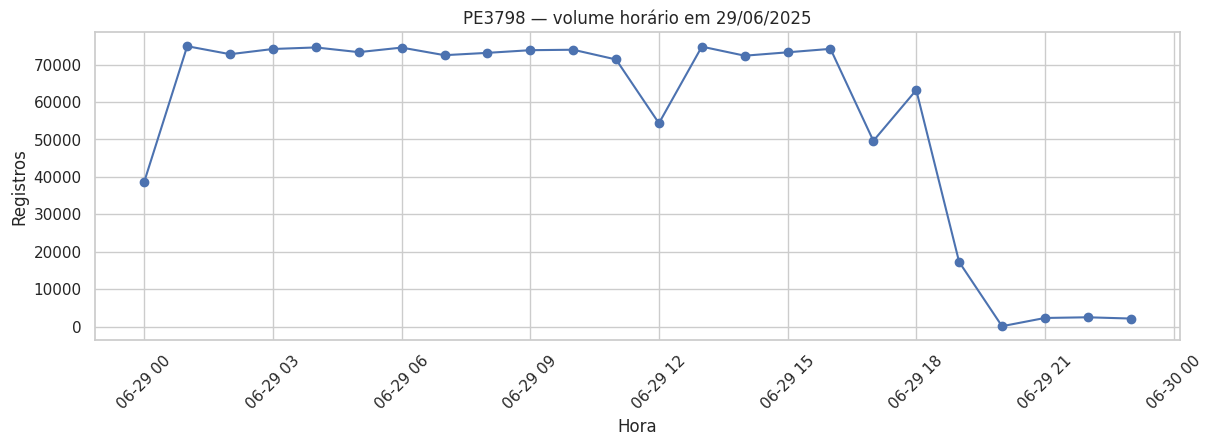

In [12]:
REMOTE_PTO_SIGNALS = (
    "Remote PTO Preprogrammed Speed Control Switch - Not Configured",
    "Remote PTO Preprogrammed Speed Control Switch - Switch Off",
)

pe3798_transitions = query(
    f'''
    WITH ordered AS (
      SELECT Data_Evento, trim(Alarme) AS alarme,
             lead(Data_Evento) OVER (ORDER BY Data_Evento, Id_Eventos_Telemetria) AS proximo_ts,
             lead(trim(Alarme)) OVER (ORDER BY Data_Evento, Id_Eventos_Telemetria) AS proximo_alarme
      FROM tel
      WHERE TAG = 'PE3798'
        AND cast(Data_Evento AS DATE) = DATE '2025-06-29'
        AND trim(Alarme) IN {REMOTE_PTO_SIGNALS}
    )
    SELECT alarme, proximo_alarme,
           count(*) AS transicoes,
           median(date_diff('millisecond', Data_Evento, proximo_ts)) AS mediana_ms,
           avg(date_diff('millisecond', Data_Evento, proximo_ts)) AS media_ms
    FROM ordered
    WHERE proximo_alarme IS NOT NULL
    GROUP BY 1, 2
    ORDER BY transicoes DESC
    '''
)
display(pe3798_transitions)

pe3798_hourly = query(
    '''
    SELECT date_trunc('hour', Data_Evento) AS hora,
           count(*) AS registros,
           count(DISTINCT Data_Evento) AS timestamps_distintos,
           count(DISTINCT Alarme) AS alarmes
    FROM tel
    WHERE TAG = 'PE3798' AND cast(Data_Evento AS DATE) = DATE '2025-06-29'
    GROUP BY 1 ORDER BY 1
    '''
)
display(pe3798_hourly)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pe3798_hourly["hora"], pe3798_hourly["registros"], marker="o")
ax.set(title="PE3798 — volume horário em 29/06/2025", xlabel="Hora", ylabel="Registros")
plt.xticks(rotation=45)
plt.show()

#### Relação com a operação

Os registros são cruzados com os apontamentos do mesmo instante. Se o padrão ocorresse apenas durante
um estado específico, isso poderia apoiar uma interpretação operacional. A presença durante estados
distintos mostra que a taxa elevada não é explicada apenas pela classificação `Operando` ou `Parado`.

Também verificamos operadores e turnos para avaliar se o pico está restrito a uma pessoa ou troca de
turno. O padrão atravessa múltiplos operadores, reduzindo a plausibilidade de uma causa exclusivamente
associada a um operador.

In [13]:
pe3798_operational = query(
    '''
    SELECT coalesce(a.Classe, 'SEM_APONTAMENTO_NO_INSTANTE') AS classe_operacional,
           count(*) AS registros,
           count(DISTINCT t.Data_Evento) AS timestamps_distintos,
           count(DISTINCT t.Alarme) AS alarmes
    FROM tel t
    LEFT JOIN ap a
      ON t.TAG = a.Tag
     AND t.Data_Evento >= a.Inicio
     AND t.Data_Evento < a.Fim
    WHERE t.TAG = 'PE3798' AND cast(t.Data_Evento AS DATE) = DATE '2025-06-29'
    GROUP BY 1 ORDER BY registros DESC
    '''
)
pe3798_operators = query(
    '''
    SELECT Nome_Operador_Anon, count(*) AS registros,
           min(Data_Evento) AS inicio, max(Data_Evento) AS fim,
           count(DISTINCT Alarme) AS alarmes
    FROM tel
    WHERE TAG = 'PE3798' AND cast(Data_Evento AS DATE) = DATE '2025-06-29'
    GROUP BY 1 ORDER BY registros DESC
    '''
)
display(pe3798_operational)
display(pe3798_operators)

,classe_operacional,registros,timestamps_distintos,alarmes
0,Operando,972083,963049,34
1,Parado,361982,354793,34


,Nome_Operador_Anon,registros,inicio,fim,alarmes
0,OP_042,838028,2025-06-29 06:00:00.017,2025-06-29 17:40:58.957,36
1,OP_308,408541,2025-06-29 00:00:01.390,2025-06-29 05:59:59.930,38
2,OP_065,85519,2025-06-29 18:10:41.073,2025-06-29 23:57:56.303,31
3,OP_275,1977,2025-06-29 18:08:53.660,2025-06-29 18:10:40.980,9


#### Conclusão do drill-down e decisão proporcional

**Evidências confirmadas**

- O volume de 29/06 é aproximadamente 32 vezes a mediana diária da própria PE3798 e 17,5 vezes
  maior que seu segundo maior dia.
- IDs e eventos lógicos são únicos; portanto, o pico não é explicado por duplicação exata.
- Dois estados Remote PTO somam aproximadamente 1,29 milhão de registros.
- Esses estados alternam quase perfeitamente, com intervalos medianos de dezenas de milissegundos.
- O padrão atravessa horas, operadores e estados operacionais.
- Não há linha `Is_Dont_Go = 1` nesse dia.

**Interpretação permitida pelos dados**

Existe emissão anormal e altamente repetitiva dos dois sinais Remote PTO. A fonte disponível não
permite afirmar se a causa foi sensor físico, configuração, firmware ou aquisição.

**Decisão**

Não remover o dia inteiro. Outros alarmes do período podem conter informação operacional válida.
Na preparação dos dados, criar uma flag específica para o par Remote PTO no intervalo observado e
avaliar estratégias como limitar sua contribuição por janela ou removê-lo apenas de features de
volume. A decisão final permanece pendente de validação operacional.

## 9. Auditoria dos apontamentos operacionais

Os apontamentos descrevem intervalos de estado operacional. Verificamos:

- IDs e datas ausentes;
- duração zero ou negativa;
- sobreposições dentro da mesma TAG;
- relações entre TAG, frota e tipo.

Sobreposição é uma inconsistência temporal relevante porque um equipamento não deveria ocupar dois
estados mutuamente exclusivos ao mesmo tempo. Porém, antes de corrigir, precisamos identificar se
o problema é duplicidade, granularidade, atraso de registro ou outra regra operacional.

In [14]:
ap_quality = query(
    '''
    SELECT count(*) AS registros,
           count(*) - count(DISTINCT Id) AS ids_repetidos_excedentes,
           sum(Inicio IS NULL OR Fim IS NULL) AS datas_nulas,
           sum(Fim < Inicio) AS duracao_negativa,
           sum(Fim = Inicio) AS duracao_zero
    FROM ap
    '''
)
display(ap_quality)

ap_overlaps = query(
    '''
    WITH ordered AS (
      SELECT *,
             lag(Fim) OVER (PARTITION BY Tag ORDER BY Inicio, Fim, Id) AS fim_anterior,
             lag(Id) OVER (PARTITION BY Tag ORDER BY Inicio, Fim, Id) AS id_anterior
      FROM ap
    )
    SELECT Tag, count(*) AS sobreposicoes,
           sum(date_diff('second', Inicio, fim_anterior)) AS segundos_sobrepostos
    FROM ordered
    WHERE Inicio < fim_anterior
    GROUP BY Tag ORDER BY sobreposicoes DESC
    '''
)
display(ap_overlaps)

ap_profile_conflicts = query(
    '''
    SELECT Tag, count(DISTINCT Frota) AS frotas, count(DISTINCT Tipo) AS tipos,
           list(DISTINCT Frota ORDER BY Frota) AS valores_frota,
           list(DISTINCT Tipo ORDER BY Tipo) AS valores_tipo
    FROM ap GROUP BY Tag
    HAVING count(DISTINCT Frota) > 1 OR count(DISTINCT Tipo) > 1
    ORDER BY Tag
    '''
)
display(ap_profile_conflicts)

,registros,ids_repetidos_excedentes,datas_nulas,duracao_negativa,duracao_zero
0,377907,0,0.0,0.0,0.0


,Tag,sobreposicoes,segundos_sobrepostos
0,CA65789,427,950400.0


,Tag,frotas,tipos,valores_frota,valores_tipo


## 10. Significado observado de `Is_Dont_Go`

O dicionário define `Is_Dont_Go` como uma flag associada à lista Don't Go. Para avaliar o que a flag
representa nos dados, examinamos criticidade, classe da telemetria e estado operacional no instante
do evento.

O cruzamento temporal utiliza somente linhas positivas, reduzindo o custo computacional. Quando há
sobreposição de apontamentos, mais de uma classe pode coincidir com o mesmo instante; esses casos
devem permanecer explicitamente identificados.

In [15]:
positive_profile = query(
    '''
    SELECT Criticidade, Classe, count(*) AS linhas,
           count(DISTINCT TAG) AS tags,
           count(DISTINCT Alarme) AS alarmes
    FROM tel WHERE Is_Dont_Go = 1
    GROUP BY Criticidade, Classe
    ORDER BY linhas DESC
    '''
)
display(positive_profile)

operational_at_positive = query(
    '''
    WITH matched AS (
      SELECT t.Id_Eventos_Telemetria, t.TAG, t.Data_Evento,
             count(a.Id) AS apontamentos_coincidentes,
             string_agg(DISTINCT a.Classe, ', ' ORDER BY a.Classe) AS classes_operacionais
      FROM tel t
      LEFT JOIN ap a
        ON t.TAG = a.Tag
       AND t.Data_Evento >= a.Inicio
       AND t.Data_Evento < a.Fim
      WHERE t.Is_Dont_Go = 1
      GROUP BY 1, 2, 3
    )
    SELECT coalesce(classes_operacionais, 'SEM_APONTAMENTO_NO_INSTANTE') AS classes_operacionais,
           count(*) AS linhas_dont_go,
           sum(apontamentos_coincidentes > 1) AS com_sobreposicao
    FROM matched
    GROUP BY 1 ORDER BY linhas_dont_go DESC
    '''
)
display(operational_at_positive)

print("Interpretação limitada aos dados: a flag identifica linhas marcadas, mas não confirma sozinha parada ou falha física.")

,Criticidade,Classe,linhas,tags,alarmes
0,Critico,Activate,10267,28,16
1,Não Crítico,Activate,9528,26,12
2,Não Crítico,NULL,148,3,1
3,Critico,NULL,19,3,2


,classes_operacionais,linhas_dont_go,com_sobreposicao
0,Operando,16118,0.0
1,Manutenção,2525,0.0
2,Parado,1184,0.0
3,Hibernando,131,0.0
4,"Hibernando, Operando",4,4.0


Interpretação limitada aos dados: a flag identifica linhas marcadas, mas não confirma sozinha parada ou falha física.


## 11. Linhas positivas versus episódios candidatos

Alertas consecutivos podem representar repetição do mesmo episódio. Para mostrar a sensibilidade da
contagem, agrupamos linhas positivas por TAG e alarme usando diferentes intervalos de separação.

Não escolhemos ainda um intervalo definitivo. Essa escolha deve considerar a dinâmica operacional
dos alarmes e, idealmente, validação com especialistas ou eventos de manutenção confirmados.

In [16]:
episode_sensitivity = query(
    '''
    WITH gaps AS (
      SELECT TAG, Alarme, Data_Evento,
             date_diff('second',
               lag(Data_Evento) OVER (PARTITION BY TAG, Alarme ORDER BY Data_Evento),
               Data_Evento) AS gap_s
      FROM tel WHERE Is_Dont_Go = 1
    )
    SELECT count(*) AS linhas_positivas,
           sum(gap_s IS NULL OR gap_s > 3600) AS episodios_gap_1h,
           sum(gap_s IS NULL OR gap_s > 14400) AS episodios_gap_4h,
           sum(gap_s IS NULL OR gap_s > 28800) AS episodios_gap_8h
    FROM gaps
    '''
)
display(episode_sensitivity)

,linhas_positivas,episodios_gap_1h,episodios_gap_4h,episodios_gap_8h
0,19962,4428.0,2794.0,2317.0


## 12. Catálogo de regras de negócio

O catálogo contém mais condições do que o nome do evento: tipo, situação, quantidade, tempo e nível.
Primeiro avaliamos cobertura nominal, isto é, se o nome dos alarmes positivos aparece no catálogo.

Cobertura nominal não prova que a regra completa foi satisfeita. A aplicação correta dependerá da
interpretação de `SITUACAO`, `QTD` e `TEMPO`, além da disponibilidade dos campos necessários.

In [17]:
rules_summary = pd.DataFrame({
    "metrica": ["regras", "eventos", "tipos", "situacoes", "niveis", "qtd_nula", "tempo_nulo"],
    "valor": [
        len(rules), rules["EVENTO"].nunique(), rules["TIPO"].nunique(),
        rules["SITUACAO"].nunique(), rules["NIVEL"].nunique(),
        rules["QTD"].isna().sum(), rules["TEMPO"].isna().sum(),
    ],
})
display(rules_summary)

con.register("rules_cma", rules)
rule_coverage = query(
    '''
    SELECT count(*) AS linhas_positivas,
           sum(r.EVENTO IS NOT NULL) AS evento_presente_catalogo,
           sum(r.EVENTO IS NULL) AS evento_ausente_catalogo
    FROM tel t
    LEFT JOIN (SELECT DISTINCT EVENTO FROM rules_cma) r ON t.Alarme = r.EVENTO
    WHERE t.Is_Dont_Go = 1
    '''
)
display(rule_coverage)

unavailable_rule_fields = pd.DataFrame({
    "condicao_regra": ["TIPO", "EVENTO", "SITUACAO", "QTD", "TEMPO", "NIVEL"],
    "campo_direto_na_telemetria": ["Tipo", "Alarme", "Não identificado diretamente",
                                    "Exige agregação temporal", "Exige interpretação temporal",
                                    "Não identificado diretamente"],
    "status": ["Disponível", "Disponível", "Requer investigação", "Derivável após definição",
               "Derivável após definição", "Requer investigação"],
})
display(unavailable_rule_fields)

,metrica,valor
0,regras,151
1,eventos,136
2,tipos,3
3,situacoes,19
4,niveis,3
5,qtd_nula,0
6,tempo_nulo,0


,linhas_positivas,evento_presente_catalogo,evento_ausente_catalogo
0,19962,19962.0,0.0


,condicao_regra,campo_direto_na_telemetria,status
0,TIPO,Tipo,Disponível
1,EVENTO,Alarme,Disponível
2,SITUACAO,Não identificado diretamente,Requer investigação
3,QTD,Exige agregação temporal,Derivável após definição
4,TEMPO,Exige interpretação temporal,Derivável após definição
5,NIVEL,Não identificado diretamente,Requer investigação


## 13. Registro de decisões desta etapa

O registro abaixo diferencia decisões já sustentadas pelos dados de decisões ainda pendentes.
Nenhuma limpeza destrutiva foi aplicada neste notebook.

In [18]:
decision_log = pd.DataFrame([
    {
        "tema": "Arquivos brutos",
        "evidencia": "Fontes consultadas diretamente em data/raw",
        "decisao": "Preservar sem alterações",
        "status": "Aprovada",
    },
    {
        "tema": "TAGs semelhantes",
        "evidencia": "Perfis e coexistência temporal apresentados na seção 6",
        "decisao": "Preservar identificadores originais; não fundir por similaridade textual",
        "status": "Aprovada",
    },
    {
        "tema": "Duplicatas lógicas",
        "evidencia": "Separação entre duplicatas exatas e repetições contextualmente diferentes",
        "decisao": "Deduplicar apenas cópias exatas na camada analítica; investigar as demais",
        "status": "Parcialmente aprovada",
    },
    {
        "tema": "Espaços externos em nomes de alarme",
        "evidencia": "Linhas e categorias afetadas apresentadas na seção 4",
        "decisao": "Tratar como erro de padronização em camada derivada, preservando o valor bruto",
        "status": "Aprovada",
    },
    {
        "tema": "ID de alarme associado a múltiplos nomes",
        "evidencia": "Conflitos antes e após normalização por trim apresentados na seção 4",
        "decisao": "Investigar codificação e semântica antes de consolidar nomes",
        "status": "Pendente de validação",
    },
    {
        "tema": "Volume anômalo",
        "evidencia": "Critério mediana + 10×MAD por TAG e composição dos candidatos",
        "decisao": "Criar flag; não classificar automaticamente como falha de sensor",
        "status": "Pendente de validação",
    },
    {
        "tema": "PE3798 em 29/06/2025",
        "evidencia": "Dois sinais Remote PTO alternam em dezenas de milissegundos e explicam o excesso",
        "decisao": "Não remover o dia; marcar o par de sinais e avaliar tratamento localizado",
        "status": "Pendente de validação operacional",
    },
    {
        "tema": "Is_Dont_Go",
        "evidencia": "Criticidade, estado operacional e catálogo de regras",
        "decisao": "Não interpretar isoladamente como falha ou parada confirmada",
        "status": "Aprovada",
    },
    {
        "tema": "Downtime e ROI",
        "evidencia": "Target ainda não representa parada confirmada",
        "decisao": "Não calcular até definir episódios e vínculo operacional válido",
        "status": "Aprovada",
    },
])
display(decision_log)

,tema,evidencia,decisao,status
0,Arquivos brutos,Fontes consultadas diretamente em data/raw,Preservar sem alterações,Aprovada
1,TAGs semelhantes,Perfis e coexistência temporal apresentados na...,Preservar identificadores originais; não fundi...,Aprovada
2,Duplicatas lógicas,Separação entre duplicatas exatas e repetições...,Deduplicar apenas cópias exatas na camada anal...,Parcialmente aprovada
3,Espaços externos em nomes de alarme,Linhas e categorias afetadas apresentadas na s...,Tratar como erro de padronização em camada der...,Aprovada
4,ID de alarme associado a múltiplos nomes,Conflitos antes e após normalização por trim a...,Investigar codificação e semântica antes de co...,Pendente de validação
5,Volume anômalo,Critério mediana + 10×MAD por TAG e composição...,Criar flag; não classificar automaticamente co...,Pendente de validação
6,PE3798 em 29/06/2025,Dois sinais Remote PTO alternam em dezenas de ...,Não remover o dia; marcar o par de sinais e av...,Pendente de validação operacional
7,Is_Dont_Go,"Criticidade, estado operacional e catálogo de ...",Não interpretar isoladamente como falha ou par...,Aprovada
8,Downtime e ROI,Target ainda não representa parada confirmada,Não calcular até definir episódios e vínculo o...,Aprovada


## 14. Conclusão e próximos requisitos

Este notebook estabelece uma base de investigação sem remover registros e sem converter anomalias em
erros por suposição. Os resultados devem orientar a preparação da base auditada.

### Próximas decisões necessárias

1. Definir a interpretação executável das regras `SITUACAO`, `QTD`, `TEMPO` e `NIVEL`.
2. Avaliar a origem das duplicatas lógicas e decidir se representam retransmissão ou eventos válidos.
3. Investigar operacionalmente os candidatos de volume anômalo antes de qualquer exclusão.
4. Resolver ou representar explicitamente sobreposições dos apontamentos.
5. Definir episódios de alerta com critério operacional validado.
6. Somente depois dessas decisões, construir uma variável alvo e uma base de modelagem.

### Regra para a próxima etapa

Qualquer tratamento deverá incluir uma tabela de controle com registros antes, registros afetados,
registros depois, regra aplicada e justificativa baseada nas evidências deste notebook.